In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [7]:
function simulate_OU(k, D, dt, T, r0)
    nsteps = Int(T/dt)
    r = zeros(nsteps)
    r[1] = r0

    for i in 2:nsteps
        ξ = randn()
        r[i] = r[i-1] - k * r[i-1] * dt + sqrt(2 * D * dt) * ξ

        # optional: avoid negative distance
        if r[i] < 0
            r[i] = 0.0
        end
    end

    return r
end

simulate_OU (generic function with 1 method)

In [29]:
k = 0.029
D = 0.198
dt = 0.01
T = 600
r0 =  31.622* 2.5
lambda_1 = simulate_OU(k, D, dt, T, r0)

60000-element Vector{Float64}:
 79.055
 78.9409626184708
 78.94425510298478
 78.93753536030226
 78.82060711770579
 78.8368712658057
 78.94907127503426
 78.90999459057288
 78.92431242741594
 78.96501484289671
  ⋮
  2.284752625137795
  2.3397786232270206
  2.2273130376282695
  2.2506538057792302
  2.3788652300363493
  2.369241928618921
  2.4181331469084606
  2.4296487638344337
  2.438600754868976

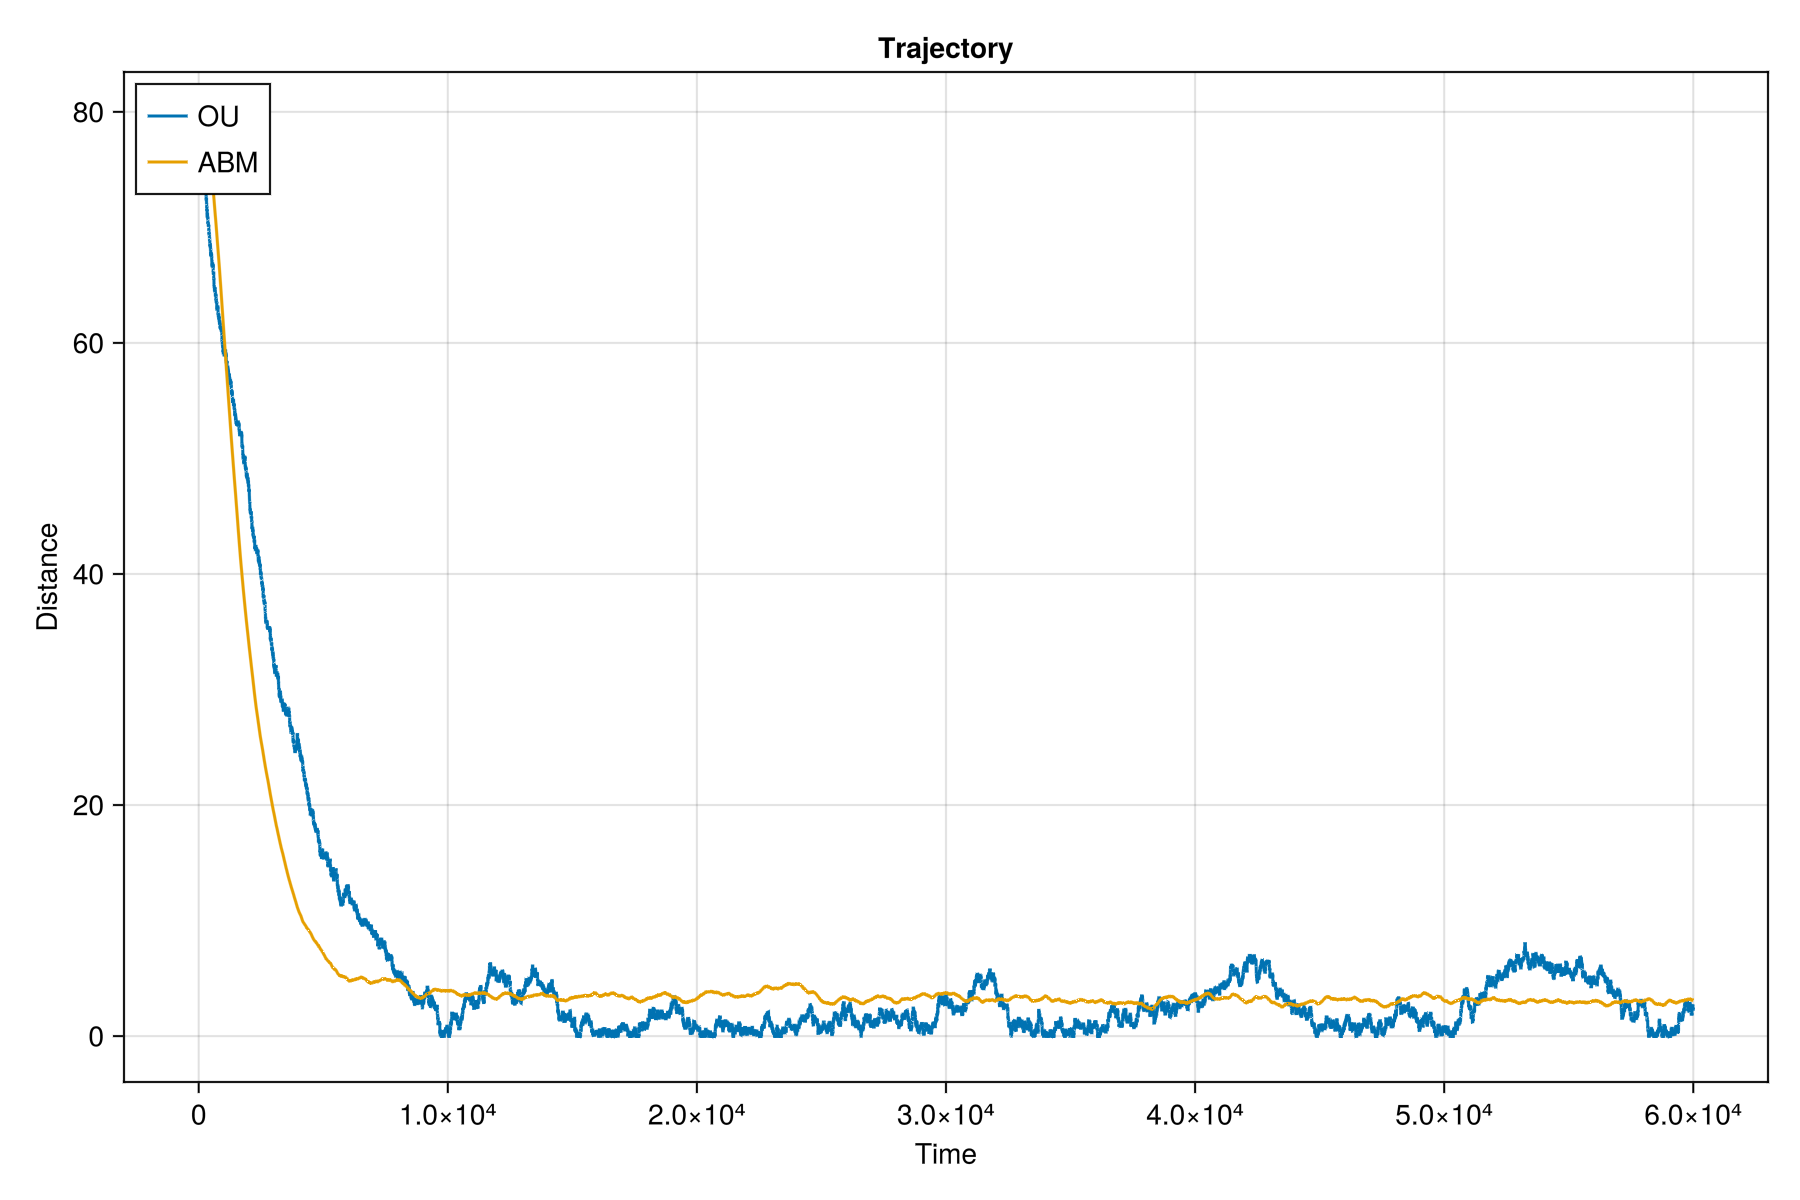

GLMakie.Screen(...)

In [30]:
fig = Figure(size=(900,600))
ax = Axis(fig[1,1], title = "Trajectory", xlabel = "Time", ylabel = "Distance")

lines!(ax, 1:60000, lambda_1, label = "OU")

jldopen("fsb_10.0_lambda_1.0.jld2", "r") do file 
                mean_dist = Float64[]
                for step in 1:60000
                    g = file[@sprintf("step_%06d", step)]
                    # Ensure com.N is defined globally
                    xs = g["x"][1]
                    other_x = g["x"][2:1001]
                    
                    dists_x = other_x .- xs

                    push!(mean_dist, mean(dists_x))
        
                end
                
                # Plot the normalized line
                lines!(ax, 1:60000, mean_dist, label ="ABM")
            end
                
axislegend(ax, position = :lt)
display(fig)

In [31]:
save("Plots/Fixed_source_model/OU_ABM_lambda_1.png", fig)

# Separate bimodal populations


Detected 2001 cells.

--- Results ---
Total Cells: 2001
Trapped: 1666 (83.25837081459271%)
Escaped: 335 (16.741629185407298%)
Trapped Mean (μ): 4.03
Trapped Std Dev (σ): 38.53


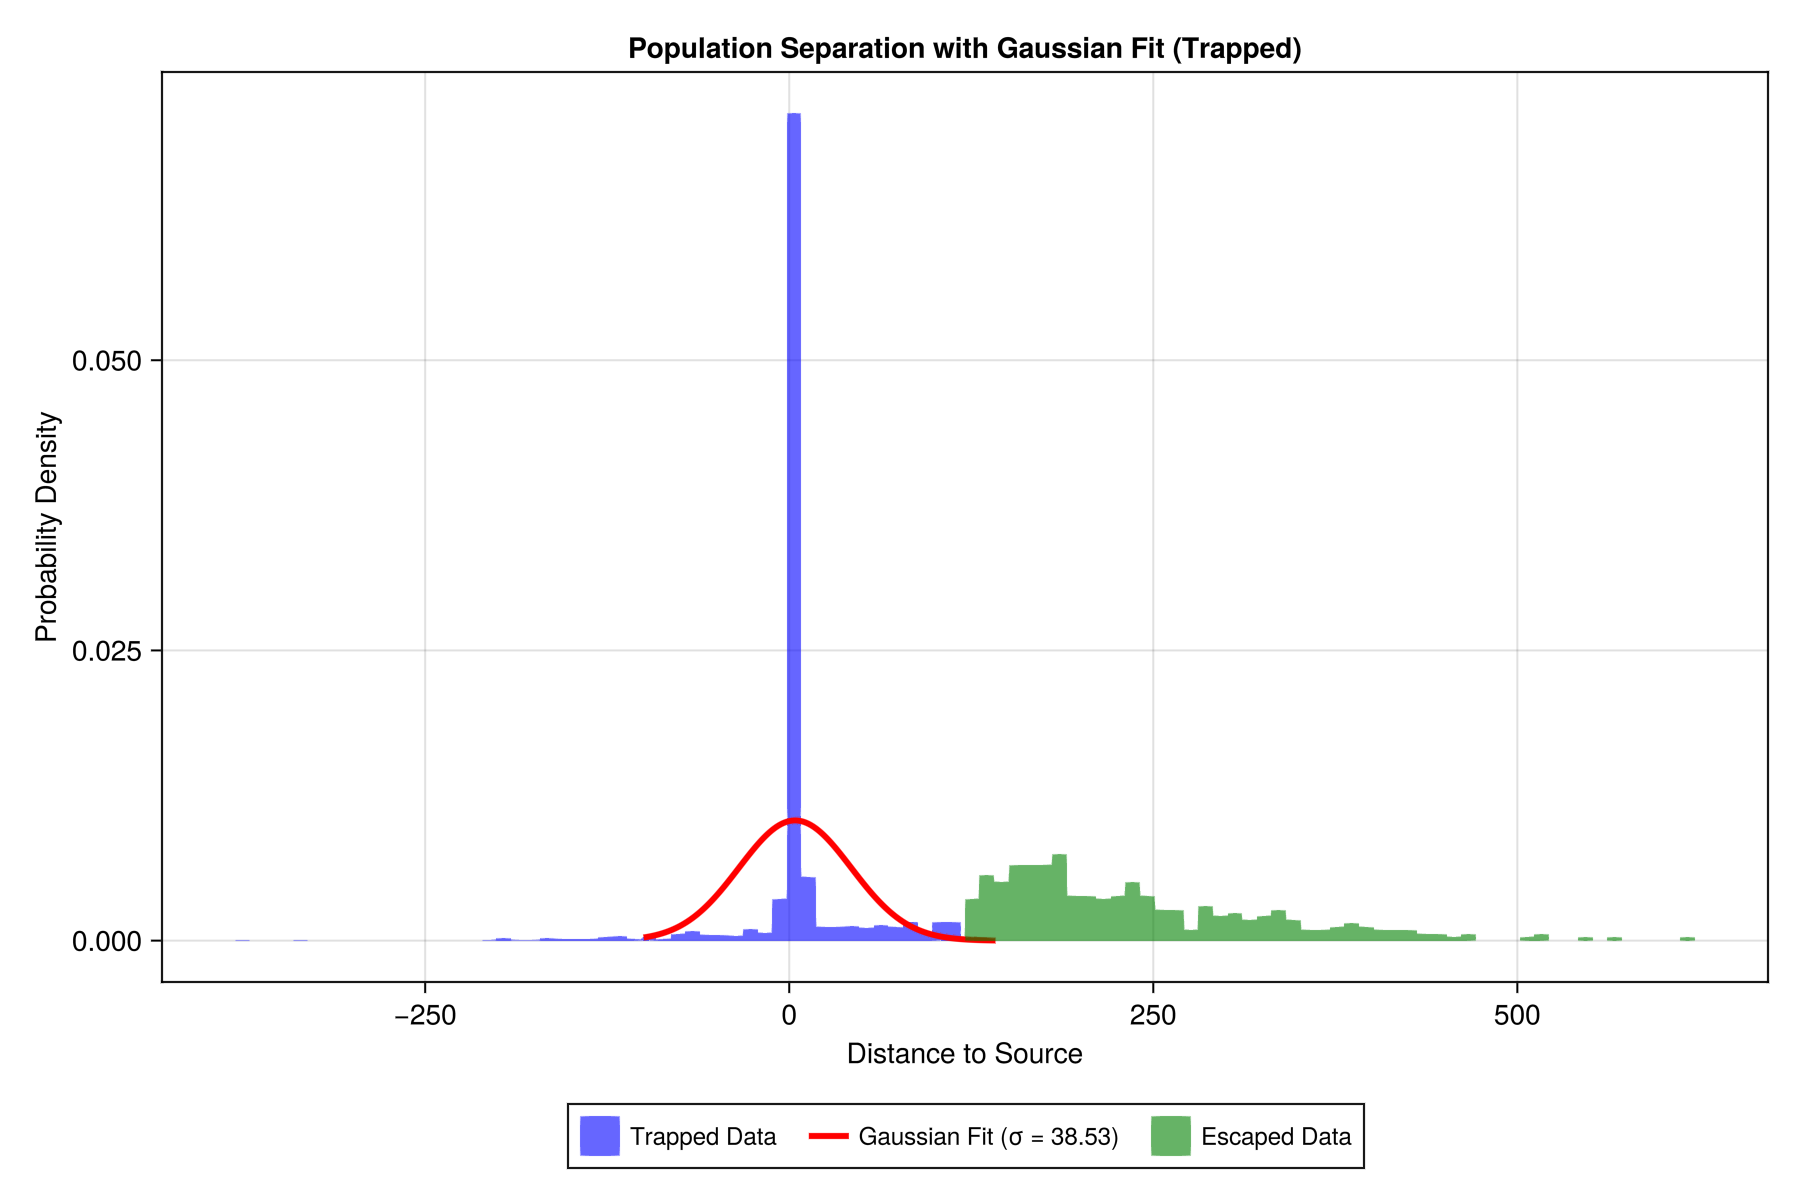

GLMakie.Screen(...)

In [78]:
using Distributions
# Configuration
filename = "fsb_10.0_lambda_10.0.jld2"
steps_total = 60000
steps_to_average = 1000 
D_crit = 120.0 

# Create Figure and Axis
fig = Figure(size = (900, 600))
ax = Axis(fig[1, 1],
          title = "Population Separation with Gaussian Fit (Trapped)",
          xlabel = "Distance to Source",
          ylabel = "Probability Density"
)

# --- DATA EXTRACTION & FITTING ---
jldopen(filename, "r") do file
    # 1. Determine number of cells
    g_sample = file["step_000001"]
    total_points = length(g_sample["x"])
    n_cells = total_points - 1
    
    println("Detected $n_cells cells.")

    sums = zeros(Float64, n_cells) 
    
    # 2. Loop through last N steps
    start_step = steps_total - steps_to_average + 1
    
    for step in start_step:steps_total
        g = file[@sprintf("step_%06d", step)]
        xs = g["x"][1]
        other_x = g["x"][2:end]
        dists = other_x .- xs
        
        for i in 1:length(dists)
            sums[i] += dists[i]
        end
    end
    
    # 3. Calculate averages
    avg_distances = sums ./ steps_to_average
    
    # 4. Separate populations
    is_trapped = avg_distances .< D_crit
    is_escaped = avg_distances .>= D_crit
    
    trapped_data = avg_distances[is_trapped]
    escaped_data = avg_distances[is_escaped]
    
    # --- GAUSSIAN FIT FOR TRAPPED POPULATION ---
    if length(trapped_data) > 1
        mu = mean(trapped_data)
        sigma = std(trapped_data)
        
        # Create x values for the smooth curve
        x_fit = range(-100, stop=maximum(trapped_data)*1.2, length=200)
        # Calculate Gaussian PDF
        gaussian_pdf = pdf.(Distributions.Normal(mu, sigma), x_fit)
        
        # Plot Trapped Histogram
        hist!(ax, trapped_data, 
                   color = :blue, 
                   alpha = 0.6, 
                   bins = 50, 
                   normalization = :pdf,
                   label = "Trapped Data")
        
        # Plot Gaussian Fit
        lines!(ax, x_fit, gaussian_pdf, 
               color = :red, 
               linewidth = 3, 
               label = "Gaussian Fit (σ = $(@sprintf("%.2f", sigma)))")
    else
        @warn "Not enough trapped cells to fit a Gaussian."
    end
    
    # Plot Escaped Histogram
    if length(escaped_data) > 0
        hist!(ax, escaped_data, 
                   color = :green, 
                   alpha = 0.6, 
                   bins = 50, 
                   normalization = :pdf,
                   label = "Escaped Data")
    end
    
    # # Plot Threshold Line
    # lines!(ax, [D_crit, D_crit], [0, 0.05], 
    #        color = :black, 
    #        linestyle = :dash, 
    #        linewidth = 2,
    #        label = "Threshold ($D_crit)")
    
    # Add Legend
    Legend(fig[2, :], ax, 
           framevisible = true, 
           framecolor = :black,
           labelsize = 12,
           orientation = :horizontal)
    
    # Print stats
    n_total = length(avg_distances)
    n_trapped = length(trapped_data)
    n_escaped = length(escaped_data)
    
    println("\n--- Results ---")
    println("Total Cells: $n_total")
    println("Trapped: $n_trapped ($(100*n_trapped/n_total)%)")
    println("Escaped: $n_escaped ($(100*n_escaped/n_total)%)")
    
    if n_trapped > 1
        println("Trapped Mean (μ): $(@sprintf("%.2f", mu))")
        println("Trapped Std Dev (σ): $(@sprintf("%.2f", sigma))")
    end
end

display(fig)

In [79]:
save("Plots/Fixed_source_model/Lambda_10_gaussian_subpopulations.png", fig)

In [ ]:
using Distributions
# Configuration
filename = "fsb_10.0_lambda_10.0.jld2"
steps_total = 60000
steps_to_average = 1000 
D_crit = 120.0 

# Create Figure and Axis
fig = Figure(size = (900, 600))
ax = Axis(fig[1, 1],
          title = "Population Separation with Gaussian Fit (Trapped)",
          xlabel = "Distance to Source",
          ylabel = "Probability Density"
)

# --- DATA EXTRACTION & FITTING ---
jldopen(filename, "r") do file
    # 1. Determine number of cells
    g_sample = file["step_000001"]
    total_points = length(g_sample["x"])
    n_cells = total_points - 1
    
    println("Detected $n_cells cells.")

    sums = zeros(Float64, n_cells) 
    
    # 2. Loop through last N steps
    start_step = steps_total - steps_to_average + 1
    
    for step in start_step:steps_total
        g = file[@sprintf("step_%06d", step)]
        xs = g["x"][1]
        other_x = g["x"][2:end]
        dists = other_x .- xs
        
        for i in 1:length(dists)
            sums[i] += dists[i]
        end
    end
    
    # 3. Calculate averages
    avg_distances = sums ./ steps_to_average
    
    # 4. Separate populations
    is_trapped = avg_distances .< D_crit
    is_escaped = avg_distances .>= D_crit
    
    trapped_data = avg_distances[is_trapped]
    escaped_data = avg_distances[is_escaped]
    
end


Base.Meta.ParseError: ParseError:
# Error @ c:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\examples\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sZmlsZQ==.jl:50:5
    escaped_data = avg_distances[is_escaped]
    
#   └ ── Expected `end`

In [4]:
function find_linear_region(time_vec, data, log_data; 
                           min_slope=-0.1, max_slope=-0.001, 
                           min_points=20)
    """
    Automatically finds the linear descent region by:
    1. Computing local slopes (derivatives)
    2. Finding where slope is consistently negative and linear
    3. Excluding plateau and equilibrium regions
    """
    
    n = length(data)
    
    # Calculate local slopes using finite differences
    slopes = zeros(n-1)
    for i in 1:(n-1)
        slopes[i] = (log_data[i+1] - log_data[i]) / (time_vec[i+1] - time_vec[i])
    end
    
    # Find where slope is in the "descent range" (negative but not too steep)
    descent_mask = (slopes .< max_slope) .& (slopes .> min_slope)
    
    # Find contiguous regions of descent
    regions = []
    start_idx = nothing
    
    for i in 1:length(descent_mask)
        if descent_mask[i] && isnothing(start_idx)
            start_idx = i
        elseif !descent_mask[i] && !isnothing(start_idx)
            end_idx = i - 1
            if (end_idx - start_idx) >= min_points
                push!(regions, (start_idx, end_idx))
            end
            start_idx = nothing
        end
    end
    
    # If we ended in a descent region, close it
    if !isnothing(start_idx) && (length(descent_mask) - start_idx) >= min_points
        push!(regions, (start_idx, length(descent_mask)))
    end
    
    # Return the longest descent region (usually the main one)
    if isempty(regions)
        println("⚠️  No clear descent region found. Using manual fallback.")
        # Fallback: use middle 50% of data
        start_idx = div(n, 4)
        end_idx = div(3*n, 4)
        return start_idx, end_idx
    else
        # Find longest region
        longest_region = reduce((a, b) -> (last(a)-first(a) > last(b)-first(b)) ? a : b, regions)
        println("📏  Found descent region: steps $(longest_region[1]) to $(longest_region[2])")
        return longest_region[1], longest_region[2] + 1  # +1 because slopes is n-1
    end
end

function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end


linear_fit (generic function with 1 method)

📏  Found descent region: steps 269 to 5686
📏  Found descent region: steps 6 to 5776


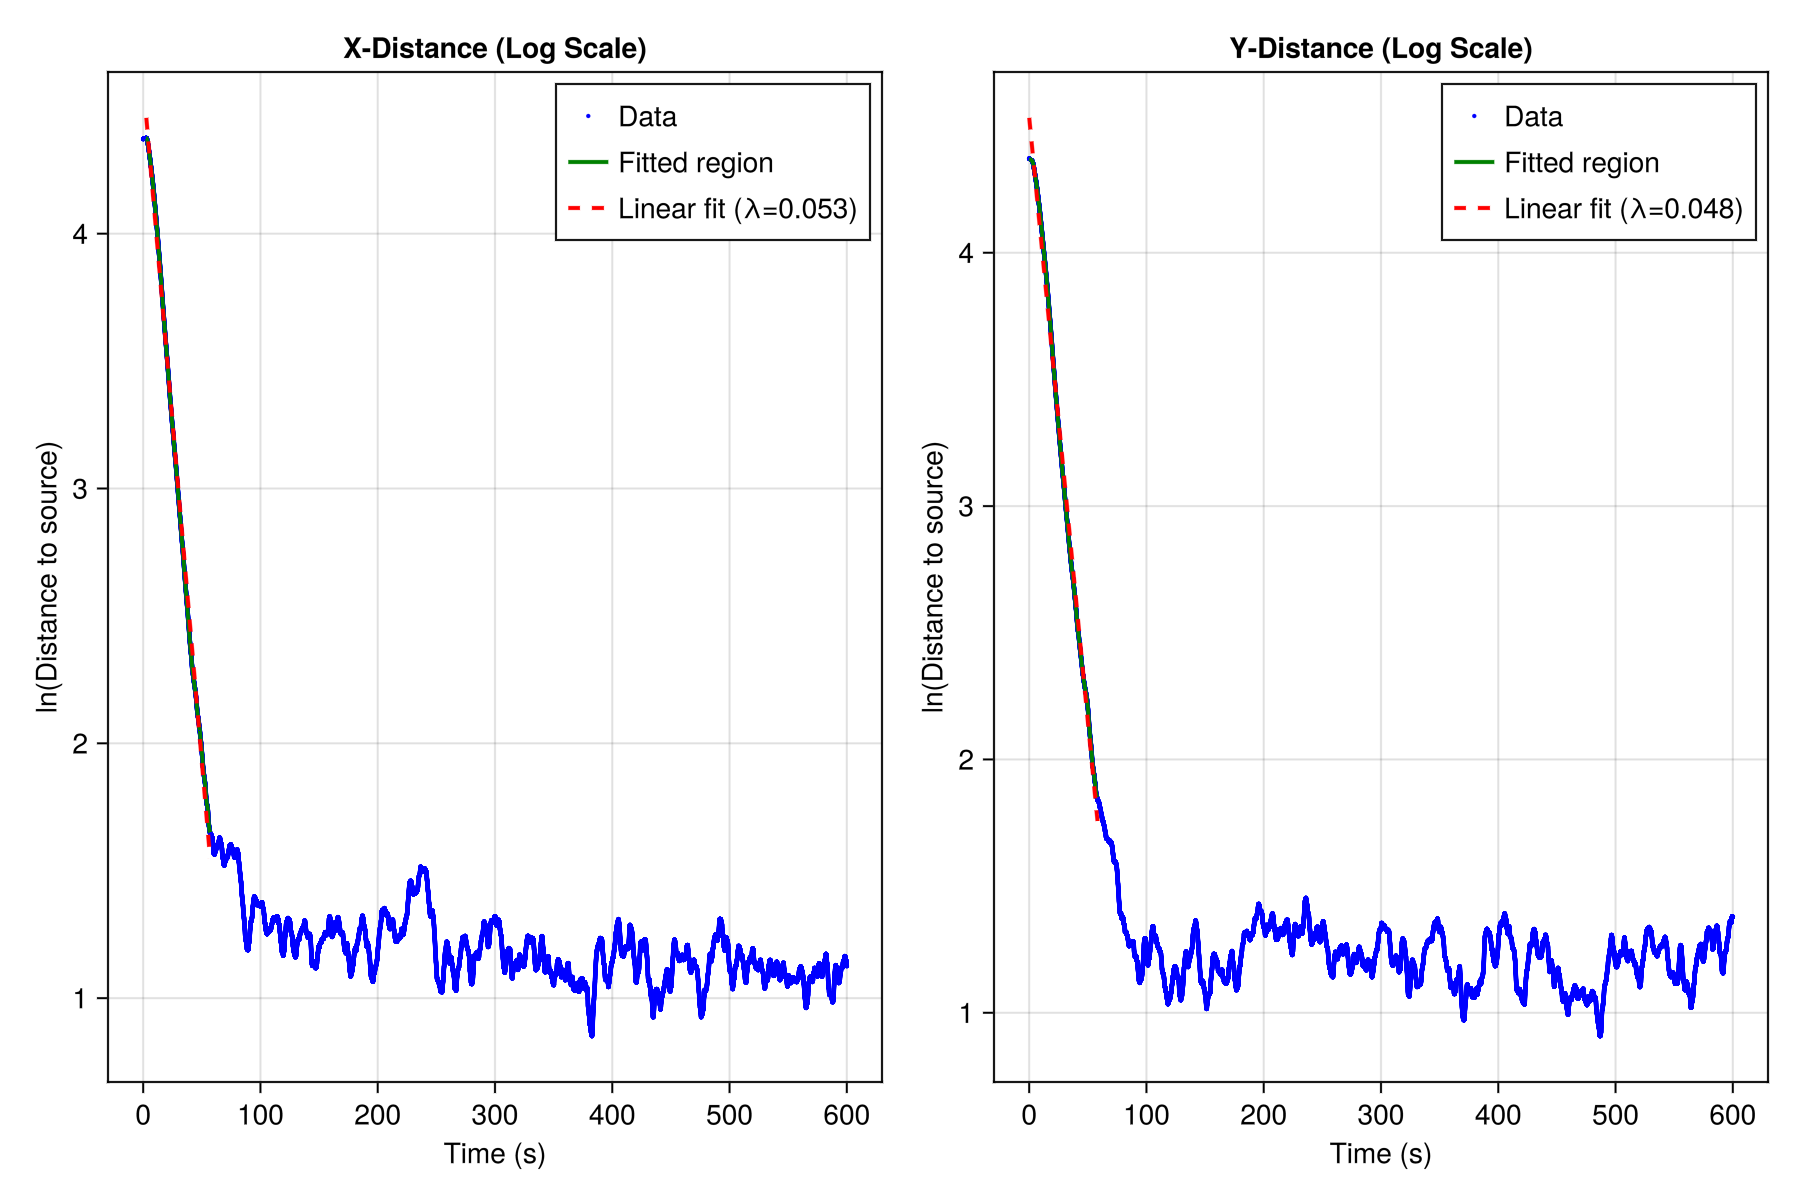

GLMakie.Screen(...)

In [86]:
steps = 60000
mean_dist_x = Float64[] 
std_dist_x = Float64[]
mean_dist_y = Float64[] 
std_dist_y = Float64[]

jldopen("fsb_10.0_lambda_1.0.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:1001]

        other_y = g["y"][2:1001]

        dists_x = other_x .- xs
        dists_y = other_y .- ys

        push!(mean_dist_x, mean(dists_x))
        push!(mean_dist_y, mean(dists_y))

    end
end

data_x = abs.(mean_dist_x)
data_y = abs.(mean_dist_y)

log_data_x = log.(data_x)
log_data_y = log.(data_y)

time_vec = (1:steps) * 0.01

start_x, end_x = find_linear_region(time_vec, data_x, log_data_x)
start_y, end_y = find_linear_region(time_vec, data_y, log_data_y)

slope_x, intercept_x = linear_fit(time_vec[start_x:end_x], log_data_x[start_x:end_x])
lambda_x = -slope_x  # λ = -slope

slope_y, intercept_y = linear_fit(time_vec[start_y:end_y], log_data_y[start_y:end_y])
lambda_y = -slope_y

fig_linear = Figure(size=(900, 600))

ax1 = Axis(fig_linear[1, 1], xlabel="Time (s)", ylabel="ln(Distance to source)")
scatter!(ax1, time_vec, log_data_x, color=:blue, markersize=3, label="Data")
lines!(ax1, time_vec[start_x:end_x], log_data_x[start_x:end_x], 
       color=:green, linewidth=2, label="Fitted region")

# xlims!(ax1, 0, end_x*0.01 + 100)

fitted_line_x = [intercept_x + slope_x * t for t in time_vec]

lines!(ax1, time_vec[start_x:(end_x + 20)], fitted_line_x[start_x:(end_x + 20)], color=:red, linestyle=:dash, 
        linewidth=2, label="Linear fit (λ=$(round(lambda_x, digits=3)))")
ax1.title = "X-Distance (Log Scale)"
axislegend(ax1, position=:rt)


ax2 = Axis(fig_linear[1, 2], xlabel="Time (s)", ylabel="ln(Distance to source)")
scatter!(ax2, time_vec, log_data_y, color=:blue, markersize=3, label="Data")
lines!(ax2, time_vec[start_y:end_y], log_data_y[start_y:end_y], 
       color=:green, linewidth=2, label="Fitted region")


fitted_line_y = [intercept_y + slope_y * t for t in time_vec]
lines!(ax2, time_vec[start_y:(end_y+ 50)], fitted_line_y[start_y:(end_y+ 50)], color=:red, linestyle=:dash, 
       linewidth=2, label="Linear fit (λ=$(round(lambda_y, digits=3)))")
ax2.title = "Y-Distance (Log Scale)"
axislegend(ax2, position=:rt)
# xlims!(ax2, 0, end_y*0.01 + 100)

display(fig_linear)

In [88]:
save("Plots/Fixed_source_model/Lambda_log_linfit_1.png", fig_linear)

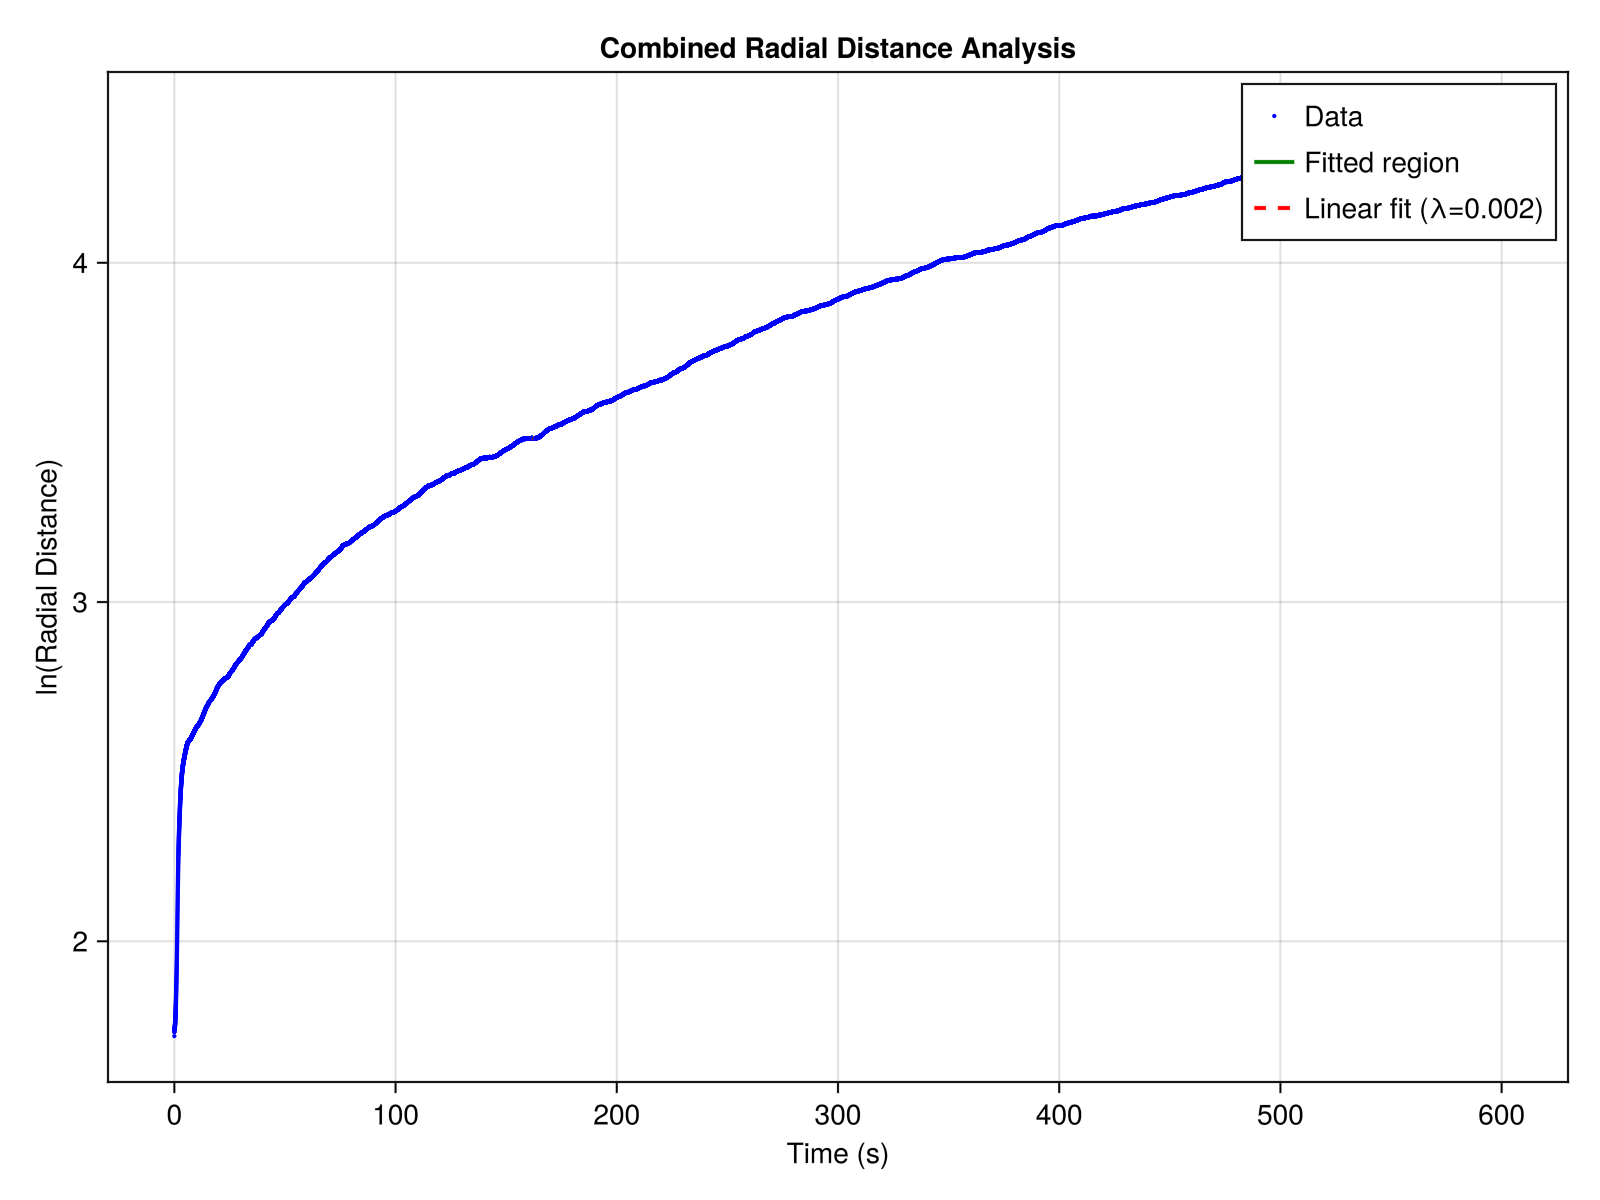

📏  Found descent region: steps 16191 to 16212


GLMakie.Screen(...)

In [5]:
filename = "fsb_10.0_lambda_10.0.jld2"
steps = 60000
dt = 0.01

# Initialize arrays
mean_dist_r = Float64[] 

# Load data
jldopen(filename, "r") do file 
    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        # Source position (cell 1)
        xs = g["x"][1]
        ys = g["y"][1]

        # Other cells (dynamically sized to avoid BoundsError)
        other_x = g["x"][2:end]
        other_y = g["y"][2:end]

        # 1. Calculate displacement vectors
        dx = other_x .- xs
        dy = other_y .- ys

        # 2. Calculate Euclidean distance for each cell: sqrt(dx^2 + dy^2)
        dists_r = sqrt.(dx.^2 .+ dy.^2)

        # 3. Store the mean radial distance for this time step
        push!(mean_dist_r, mean(dists_r))
    end
end

# Pre-processing
# Ensure positive distance (though sqrt ensures this, abs() is safe)
data_r = abs.(mean_dist_r)
log_data_r = log.(data_r)
time_vec = (1:steps) * dt

# --- ANALYSIS (Using your existing functions) ---
# Find the linear region (assuming these functions are defined in your environment)
start_idx, end_idx = find_linear_region(time_vec, data_r, log_data_r)

# Perform linear fit on the log data
slope, intercept = linear_fit(time_vec[start_idx:end_idx], log_data_r[start_idx:end_idx])

# Calculate lambda
k = -slope

# --- PLOTTING ---
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], 
          xlabel="Time (s)", 
          ylabel="ln(Radial Distance)",
          title="Combined Radial Distance Analysis")

# 1. Scatter the raw log data
scatter!(ax, time_vec, log_data_r, color=:blue, markersize=3, label="Data")

# 2. Highlight the fitted region
lines!(ax, time_vec[start_idx:end_idx], log_data_r[start_idx:end_idx], 
       color=:green, linewidth=2, label="Fitted region")

# 3. Plot the full fitted line (extrapolated)
fitted_line = [intercept + slope * t for t in time_vec]
lines!(ax, time_vec[start_idx:end_idx], fitted_line[start_idx:end_idx], color=:red, linestyle=:dash, linewidth=2, 
       label="Linear fit (λ=$(round(k, digits=3)))")

# Add legend
axislegend(ax, position=:rt)

display(fig)

In [6]:
save("Plots/Fixed_source_model/lambda_fit_loglin_10_junts.png", fig)

# Keller


In [44]:
t_vec = collect(0:0.01:100-0.01)

10000-element Vector{Float64}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.06
  0.07
  0.08
  0.09
  ⋮
 99.91
 99.92
 99.93
 99.94
 99.95
 99.96
 99.97
 99.98
 99.99

Bessel Profile Parameters:
  Equilibrium distance (r_eq): 6.84
  u = r/l: 0.2163051040414901
  K0(u): 1.6780665170119329
  K1(u): 4.3890597006142755
  Derivative term: 21.96912585222021
  Calculated Mobility (mu): 1.3199694804001223
  Check effective k: 0.029000000000000005


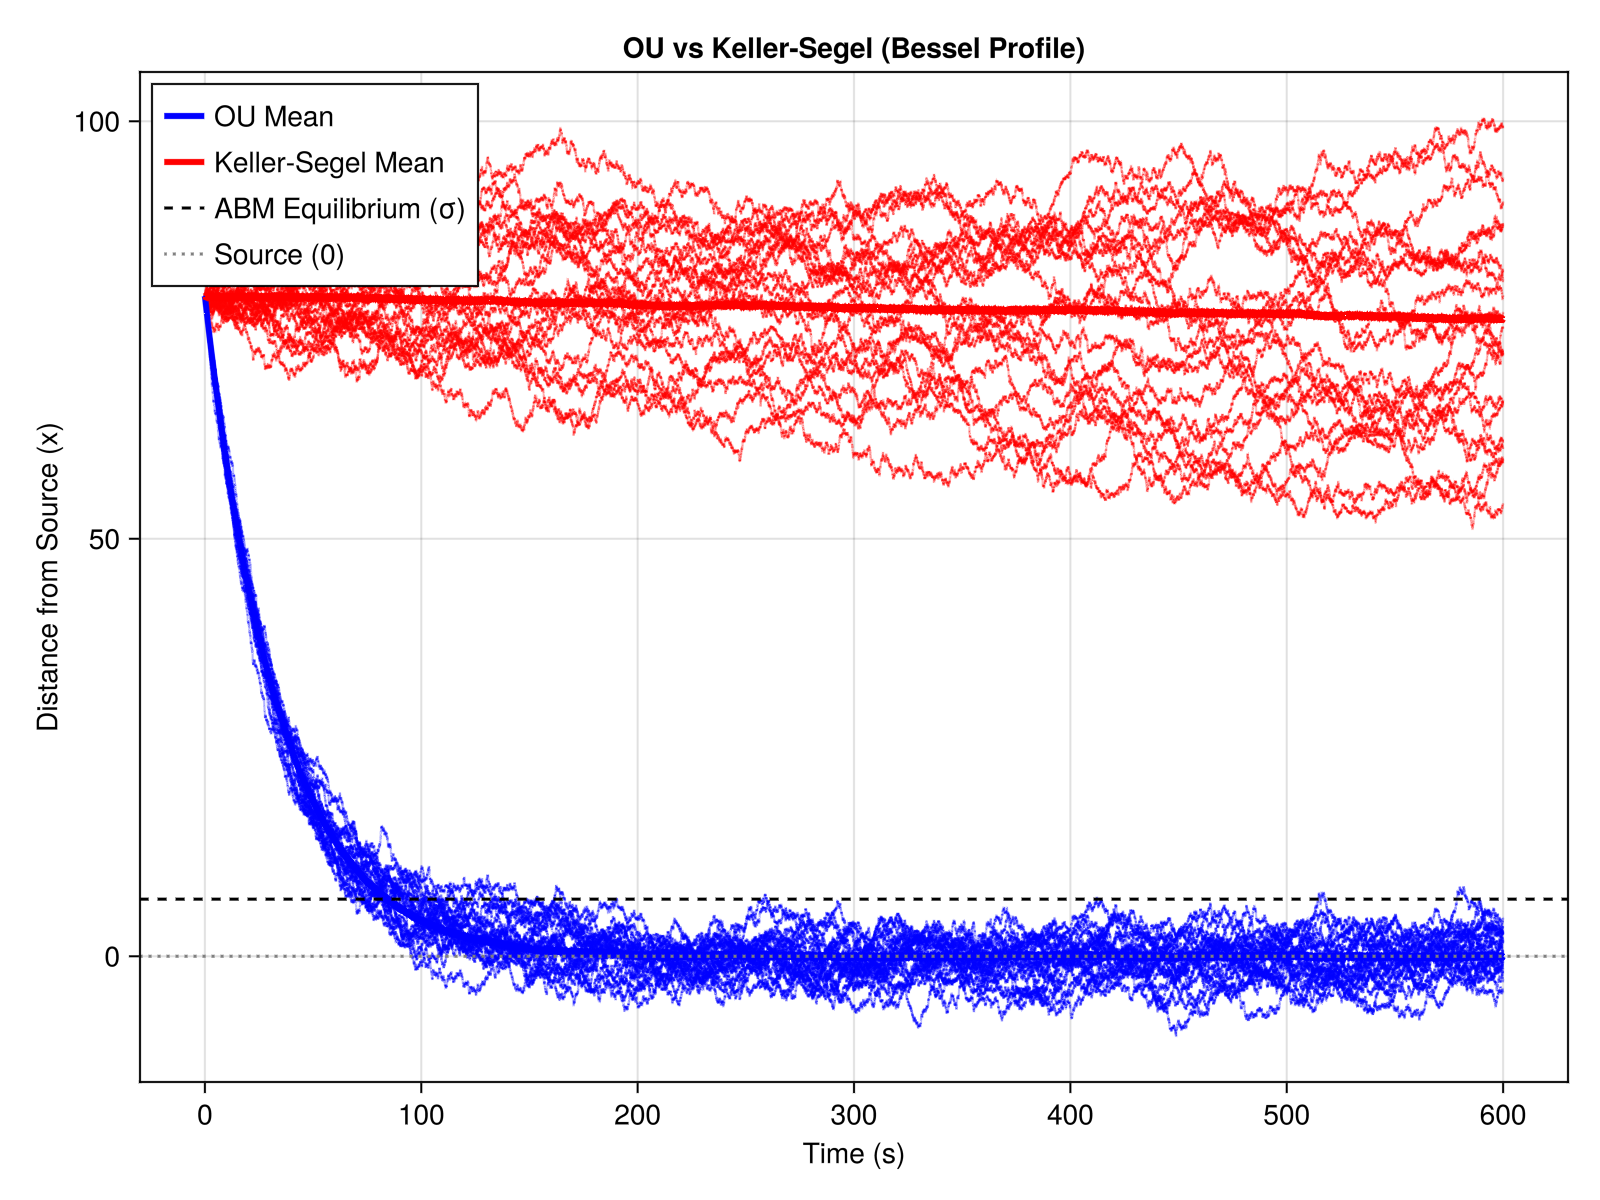

GLMakie.Screen(...)

In [65]:
# --- 1. Parameters ---
k = 0.029          # OU slope (from ABM)
sigma = 6.84       # OU equilibrium distance (from ABM)
D = 0.198          # Bacterial diffusion
Dc = 10.0          # Attractant diffusion
delta = 0.01       # Attractant degradation
l = 31.622         # Decay length = sqrt(Dc/delta)

# --- 2. Calculate mu for Bessel Profile ---
# Profile: c(r) = c0 * K0(r/l)
# Gradient: grad_c = -c0/l * K1(r/l)
# Effective slope k_eff = mu * (c0/l^2) * (K0(u) + (1/u)*K1(u)) where u = r/l

r_eq = sigma       # Equilibrium distance from source
u_eq = r_eq / l    # Dimensionless distance

# Bessel functions at equilibrium
K0_eq = besselk(0, u_eq)
K1_eq = besselk(1, u_eq)

# Derivative term: d/dr (K1(r/l)) = -1/l * (K0(r/l) + (l/r)*K1(r/l))
# The restoring force slope is: mu * c0/l * (1/l) * (K0 + (l/r)*K1)
# k = mu * (c0/l^2) * (K0 + (l/r)*K1)
# Assume c0 = 1 (normalized concentration). If your ABM uses a different scale, adjust c0.
c0 = 1.0 

# Calculate the term in the denominator
derivative_term = K0_eq + (l / r_eq) * K1_eq

# Solve for mu
mu = k * l^2 / (c0 * derivative_term)

println("Bessel Profile Parameters:")
println("  Equilibrium distance (r_eq): ", r_eq)
println("  u = r/l: ", u_eq)
println("  K0(u): ", K0_eq)
println("  K1(u): ", K1_eq)
println("  Derivative term: ", derivative_term)
println("  Calculated Mobility (mu): ", mu)
println("  Check effective k: ", mu * (c0/l^2) * derivative_term)

# --- 3. Simulation Setup ---
dt = 0.01
T = 600.0
n_steps = Int(T / dt)
n_bacteria = 1000

t_vec = collect(0:dt:T-dt)

# Initialize trajectories: Rows = Time, Cols = Bacteria
trajectories_ou = zeros(n_steps, n_bacteria)
trajectories_keller = zeros(n_steps, n_bacteria)

x_start = l * 2.5

# Correct Initialization: First row (time step 1) filled with start positions
trajectories_ou[1, :] = fill(x_start, n_bacteria)
trajectories_keller[1, :] = fill(x_start, n_bacteria)

# --- 4. Run Simulation ---
for i in 2:n_steps
    noise = randn(n_bacteria) * sqrt(2 * D * dt)
    
    # --- OU Model ---
    # r[i] = r[i-1] - k * r[i-1] * dt + noise
    trajectories_ou[i, :] = trajectories_ou[i-1, :] - k * trajectories_ou[i-1, :] * dt + noise
    
    # --- Keller-Segel Model (Bessel) ---
    x_prev = trajectories_keller[i-1, :]
    
    # Gradient: -c0/l * K1(r/l)
    # Note: x is distance, so x >= 0. K1 is defined for positive arguments.
    u = x_prev ./ l
    grad_c = -c0 / l * besselk.(1, u)
    
    # Update
    trajectories_keller[i, :] = x_prev + mu * grad_c * dt + noise
end

# --- 5. Visualization ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1],
          title = "OU vs Keller-Segel (Bessel Profile)",
          xlabel = "Time (s)",
          ylabel = "Distance from Source (x)")

# Plot individual trajectories (subset)
n_plot = 20
for j in 1:n_plot
    lines!(ax, t_vec, trajectories_ou[:, j], color = :blue, alpha = 0.3, linewidth = 1)
    lines!(ax, t_vec, trajectories_keller[:, j], color = :red, alpha = 0.3, linewidth = 1)
end

# Plot Means
mean_ou = mean(trajectories_ou, dims=2)[:, 1]
mean_keller = mean(trajectories_keller, dims=2)[:, 1]

lines!(ax, t_vec, mean_ou, color = :blue, linewidth = 3, label = "OU Mean")
lines!(ax, t_vec, mean_keller, color = :red, linewidth = 3, label = "Keller-Segel Mean")

# Reference lines
hlines!(ax, sigma, color = :black, linestyle = :dash, label = "ABM Equilibrium (σ)")
hlines!(ax, 0, color = :gray, linestyle = :dot, label = "Source (0)")

axislegend(ax, position = :lt)
display(fig)

Log-Sensitivity Bessel Parameters:
  mu: -4.639142311356582
  Check k: 0.029000000000000005


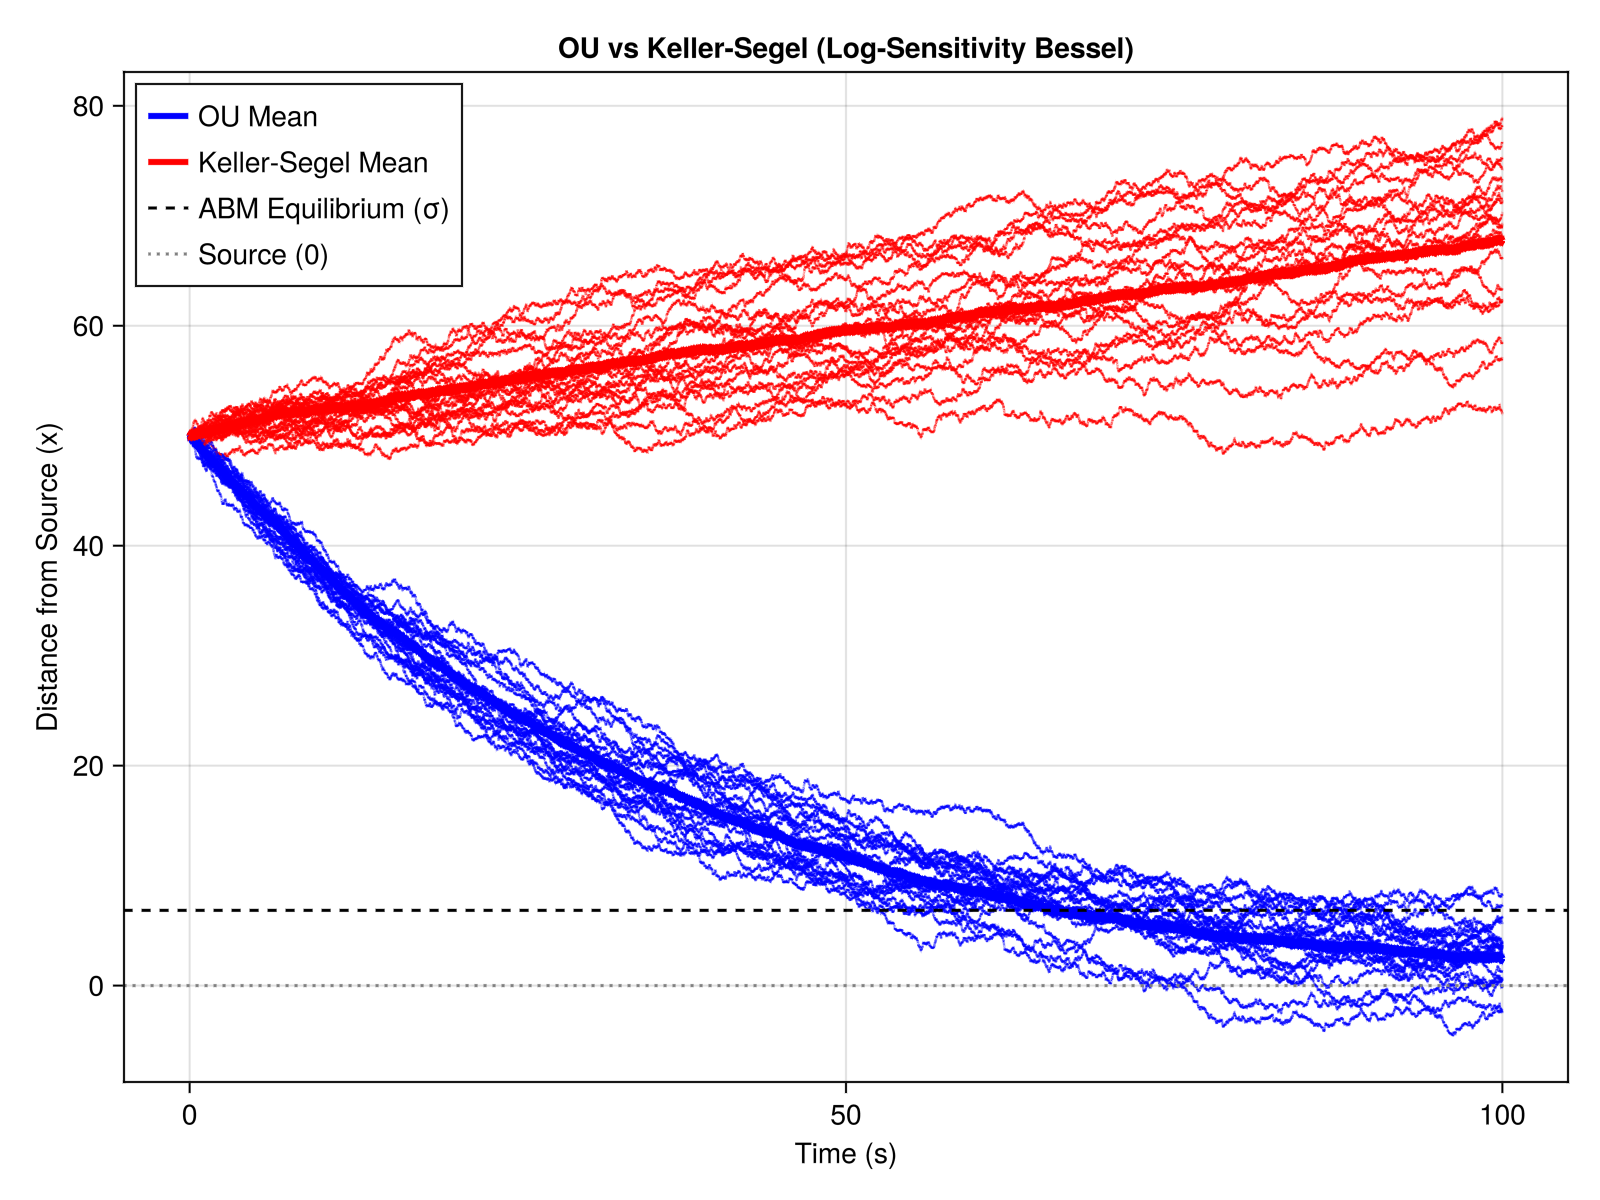

GLMakie.Screen(...)

In [67]:
# --- 1. Parameters ---
k = 0.029          # OU slope (from ABM)
sigma = 6.84       # OU equilibrium distance (from ABM)
D = 0.198          # Bacterial diffusion
Dc = 10.0          # Attractant diffusion
delta = 0.01       # Attractant degradation
l = 31.622         # Decay length = sqrt(Dc/delta)

# --- 2. Calculate mu for Log-Sensitivity Bessel ---
r_eq = sigma
u_eq = r_eq / l

K0_eq = besselk(0, u_eq)
K1_eq = besselk(1, u_eq)

ratio = K1_eq / K0_eq
derivative_log_grad = -1 - (1/u_eq) * ratio + ratio^2

# mu = k * l^2 / derivative_log_grad
mu = k * l^2 / derivative_log_grad

println("Log-Sensitivity Bessel Parameters:")
println("  mu: ", mu)
println("  Check k: ", mu * (1/l^2) * derivative_log_grad)

# --- 3. Simulation ---
dt = 0.001
T = 100.0
n_steps = Int(T / dt)
n_bacteria = 50

t_vec = collect(0:dt:T-dt)
trajectories_ou = zeros(n_steps, n_bacteria)
trajectories_keller = zeros(n_steps, n_bacteria)

x_start = 50.0
trajectories_ou[1, :] = fill(x_start, n_bacteria)
trajectories_keller[1, :] = fill(x_start, n_bacteria)

for i in 2:n_steps
    noise = randn(n_bacteria) * sqrt(2 * D * dt)
    
    # --- OU Model ---
    trajectories_ou[i, :] = trajectories_ou[i-1, :] - k * trajectories_ou[i-1, :] * dt + noise
    
    # --- Keller-Segel (Log-Sensitivity) ---
    x_prev = trajectories_keller[i-1, :]
    u = abs.(x_prev) ./ l
    u = max.(u, 1e-6)
    
    K0 = besselk.(0, u)
    K1 = besselk.(1, u)
    
    # Log-gradient w.r.t distance r
    log_grad_r = -1/l * (K1 ./ K0)
    
    # Force in 1D: F = mu * (d/dr ln c) * sign(x)
    force = mu * log_grad_r .* sign.(x_prev)
    
    trajectories_keller[i, :] = x_prev + force * dt + noise
end

# --- 4. Visualization ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1],
          title = "OU vs Keller-Segel (Log-Sensitivity Bessel)",
          xlabel = "Time (s)",
          ylabel = "Distance from Source (x)") # Allow negative x

n_plot = 20
for j in 1:n_plot
    lines!(ax, t_vec, trajectories_ou[:, j], color = :blue, alpha = 0.3, linewidth = 1)
    lines!(ax, t_vec, trajectories_keller[:, j], color = :red, alpha = 0.3, linewidth = 1)
end

mean_ou = mean(trajectories_ou, dims=2)[:, 1]
mean_keller = mean(trajectories_keller, dims=2)[:, 1]

lines!(ax, t_vec, mean_ou, color = :blue, linewidth = 3, label = "OU Mean")
lines!(ax, t_vec, mean_keller, color = :red, linewidth = 3, label = "Keller-Segel Mean")

hlines!(ax, sigma, color = :black, linestyle = :dash, label = "ABM Equilibrium (σ)")
hlines!(ax, 0, color = :gray, linestyle = :dot, label = "Source (0)")

axislegend(ax, position = :lt)
display(fig)

Loading data from fsb_10.0_lambda_1.0.jld2...
Data loaded. Steps: 60000
Estimated Equilibrium Position (x₀): 3.0629512475143152
Points used for fitting: 5316
Fitted Slope (√a): 0.9999999999999569
Estimated 'a' parameter: 0.9999999999999138
Theoretical k (from your previous OU fit): 0.029
Expected a (if mm = U = 0.5*k*x^2): 0.0145

--- NEXT STEPS ---
Use the estimated 'a' value: 0.9999999999999138
If a ≈ 0.0145 (k/2), the quadratic potential assumption is confirmed.
You can now proceed to calculate μ for the Bessel model using this 'a'.


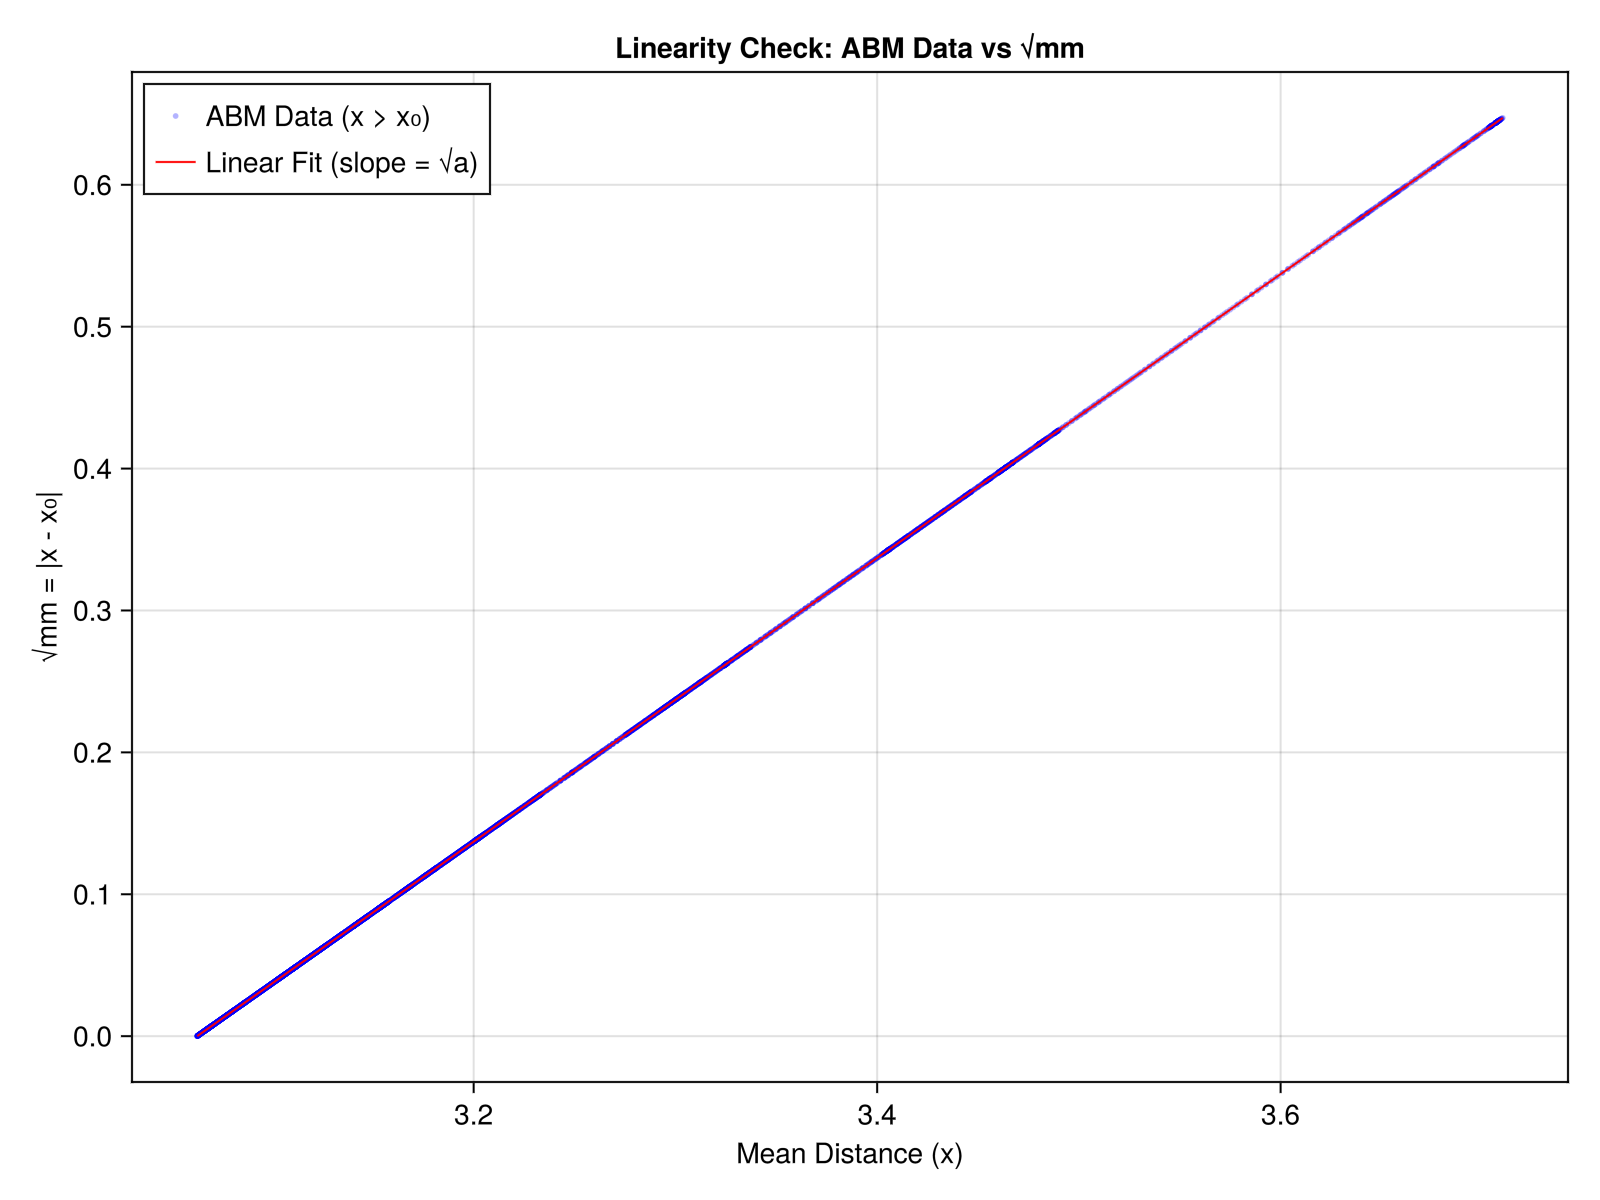

In [76]:
using GLMakie
using JLD2
using LinearAlgebra
using Printf

# --- 1. Load ABM Data from JLD2 ---
filename = "fsb_10.0_lambda_1.0.jld2" # Ensure this file is in your working directory

println("Loading data from $filename...")

mean_dist = Float64[]

jldopen(filename, "r") do file
    for step in 1:60000
        g = file[@sprintf("step_%06d", step)]
        xs = g["x"][1]
        other_x = g["x"][2:1001]
        
        # Calculate distance from the first bacterium (source or reference)
        dists_x = other_x .- xs
        
        # Store the mean distance
        push!(mean_dist, mean(dists_x))
    end
end

println("Data loaded. Steps: ", length(mean_dist))

# --- 2. Extract Equilibrium Region ---
# Use the last 20% of the data (steady state)
start_idx = Int(0.8 * length(mean_dist))
equilibrium_data = mean_dist[start_idx:end]

# Flatten to 1D (it's already 1D)
all_x = equilibrium_data

# Estimate x0 (mean of the equilibrium positions)
# Note: If your ABM is centered at 0, x0 should be ~0. 
# If it's centered elsewhere, this finds the center of the cloud.
x0_est = mean(all_x)
println("Estimated Equilibrium Position (x₀): ", x0_est)

# --- 3. Calculate mm and Prepare Data ---
# mm = a * (x - x0)^2
# We calculate (x - x0)^2 first.
diff_sq = (all_x .- x0_est).^2
sqrt_mm = sqrt.(diff_sq) # This is |x - x0|

# --- 4. Filter for Linearity (x > x0) ---
# Plot only the right side to get a straight line
mask = all_x .> x0_est
x_pos = all_x[mask]
sqrt_mm_pos = sqrt_mm[mask]

println("Points used for fitting: ", length(x_pos))

# --- 5. Linear Regression ---
# Fit: sqrt_mm = m * x + c
n = length(x_pos)
sum_x = sum(x_pos)
sum_y = sum(sqrt_mm_pos)
sum_xx = sum(x_pos.^2)
sum_xy = sum(x_pos .* sqrt_mm_pos)

slope = (n * sum_xy - sum_x * sum_y) / (n * sum_xx - sum_x^2)
intercept = (sum_y - slope * sum_x) / n

a_est = slope^2 # Since slope = sqrt(a)

println("Fitted Slope (√a): ", slope)
println("Estimated 'a' parameter: ", a_est)
println("Theoretical k (from your previous OU fit): 0.029")
println("Expected a (if mm = U = 0.5*k*x^2): ", 0.029/2)

# --- 6. Visualization ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1],
          title = "Linearity Check: ABM Data vs √mm",
          xlabel = "Mean Distance (x)",
          ylabel = "√mm = |x - x₀|")

# Scatter plot of data
scatter!(ax, x_pos, sqrt_mm_pos, color=:blue, markersize=4, alpha=0.3, label="ABM Data (x > x₀)")

# Plot the fitted line
x_fit = range(minimum(x_pos), maximum(x_pos), length=100)
y_fit = slope .* x_fit .+ intercept
lines!(ax, x_fit, y_fit, color=:red, linewidth=1, label="Linear Fit (slope = √a)")

axislegend(ax, position = :lt)

# # Add a text box with results
# text!(ax, 0.05, 0.95, 
#       "Estimated a: $(round(a_est, digits=4))\nSlope: $(round(slope, digits=4))\nR²: $(1 - (sum((sqrt_mm_pos .- (slope .* x_pos .+ intercept)).^2)) / sum((sqrt_mm_pos .- mean(sqrt_mm_pos)).^2))", 
#       size=12, halign=:left, valign=:top)

display(fig)

# --- 7. Output for Next Step ---
println("\n--- NEXT STEPS ---")
println("Use the estimated 'a' value: ", a_est)
println("If a ≈ 0.0145 (k/2), the quadratic potential assumption is confirmed.")
println("You can now proceed to calculate μ for the Bessel model using this 'a'.")

Loading data from fsb_10.0_lambda_1.0.jld2...
Experimental 'a' from ABM: 0.9999999999999138
Calculated Mobility (μ): 0.0290000000000025
Check: k = μ * a_exp = 0.029

--- Summary ---
Experimental 'a': 0.9999999999999138
Calculated 'μ': 0.0290000000000025
Check if red lines (Keller) match blue lines (OU).
If they match, the Bessel model with log-sensitivity is the correct macroscopic limit.


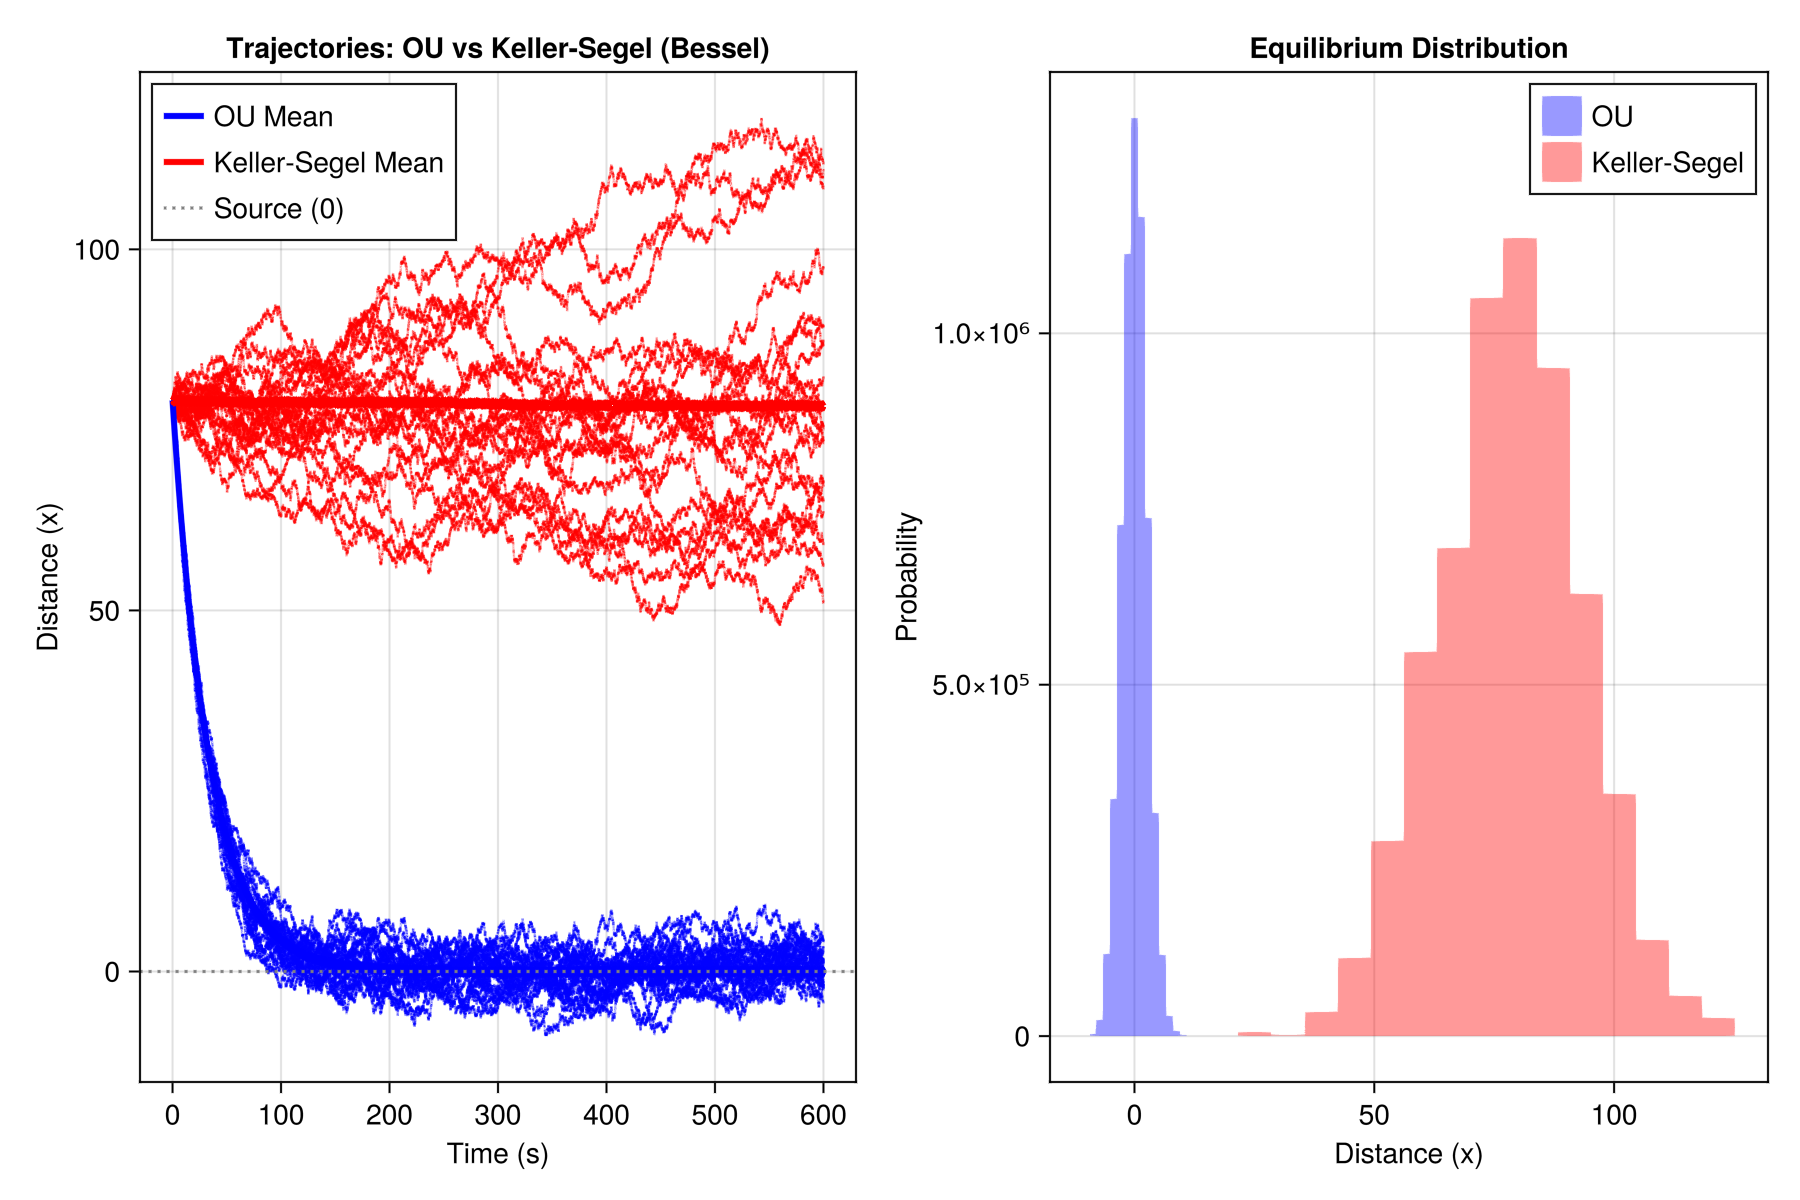

In [78]:
# ==========================================
# PART 1: Load ABM Data & Calculate 'a'
# ==========================================
filename = "fsb_10.0_lambda_1.0.jld2"

println("Loading data from $filename...")
mean_dist = Float64[]

jldopen(filename, "r") do file
    for step in 1:60000
        g = file[@sprintf("step_%06d", step)]
        xs = g["x"][1]
        other_x = g["x"][2:1001]
        dists_x = other_x .- xs
        push!(mean_dist, mean(dists_x))
    end
end

# Extract equilibrium region (last 20%)
start_idx = Int(0.8 * length(mean_dist))
all_x = mean_dist[start_idx:end]
x0_est = mean(all_x)

# Calculate mm and fit line
diff_sq = (all_x .- x0_est).^2
sqrt_mm = sqrt.(diff_sq)
mask = all_x .> x0_est
x_pos = all_x[mask]
sqrt_mm_pos = sqrt_mm[mask]

# Linear regression
n = length(x_pos)
sum_x = sum(x_pos); sum_y = sum(sqrt_mm_pos)
sum_xx = sum(x_pos.^2); sum_xy = sum(x_pos .* sqrt_mm_pos)
slope = (n * sum_xy - sum_x * sum_y) / (n * sum_xx - sum_x^2)
a_exp = slope^2 # Experimental 'a'

println("Experimental 'a' from ABM: ", a_exp)

# ==========================================
# PART 2: Define Model Parameters
# ==========================================
k = 0.029          # OU slope (from your previous fit)
sigma = 6.84       # OU std dev
D = 0.198          # Bacterial diffusion
Dc = 10.0          # Attractant diffusion
delta = 0.01       # Attractant degradation
l = sqrt(Dc / delta) # Decay length = 31.622

# Calculate Mobility (mu) using the experimental 'a'
# Relationship: k = mu * a  =>  mu = k / a
mu = k / a_exp

println("Calculated Mobility (μ): ", mu)
println("Check: k = μ * a_exp = ", mu * a_exp)

# ==========================================
# PART 3: Simulations (OU vs Keller-Segel)
# ==========================================
dt = 0.01
T = 600.0
n_steps = Int(T / dt)
n_bacteria = 1000

t_vec = collect(0:dt:T-dt)
trajectories_ou = zeros(n_steps, n_bacteria)
trajectories_keller = zeros(n_steps, n_bacteria)

x_start = l*2.5
trajectories_ou[1, :] = fill(x_start, n_bacteria)
trajectories_keller[1, :] = fill(x_start, n_bacteria)

for i in 2:n_steps
    noise = randn(n_bacteria) * sqrt(2 * D * dt)
    
    # --- OU Model ---
    trajectories_ou[i, :] = trajectories_ou[i-1, :] - k * trajectories_ou[i-1, :] * dt + noise
    
    # --- Keller-Segel (Bessel Log-Sensitivity) ---
    x_prev = trajectories_keller[i-1, :]
    u = abs.(x_prev) ./ l
    u = max.(u, 1e-6)
    
    K0 = besselk.(0, u)
    K1 = besselk.(1, u)
    
    # Log-gradient: d/dr (ln K0) = -K1/(l*K0)
    log_grad_r = -K1 ./ (l * K0)
    
    # Force: F = μ * (log_grad_r) * sign(x)
    # sign(x) ensures attraction towards 0 for both positive and negative x
    force = mu * log_grad_r .* sign.(x_prev)
    
    trajectories_keller[i, :] = x_prev + force * dt + noise
end

# ==========================================
# PART 4: Visualization
# ==========================================
fig = Figure(size = (900, 600), fontsize = 14)

# Subplot 1: Trajectories
ax1 = Axis(fig[1, 1],
           title = "Trajectories: OU vs Keller-Segel (Bessel)",
           xlabel = "Time (s)",
           ylabel = "Distance (x)")

# Plot individual trajectories (subset)
n_plot = 20
for j in 1:n_plot
    lines!(ax1, t_vec, trajectories_ou[:, j], color=:blue, alpha=0.3, linewidth=1)
    lines!(ax1, t_vec, trajectories_keller[:, j], color=:red, alpha=0.3, linewidth=1)
end

# Plot Means
mean_ou = mean(trajectories_ou, dims=2)[:, 1]
mean_keller = mean(trajectories_keller, dims=2)[:, 1]

lines!(ax1, t_vec, mean_ou, color=:blue, linewidth=3, label="OU Mean")
lines!(ax1, t_vec, mean_keller, color=:red, linewidth=3, label="Keller-Segel Mean")

hlines!(ax1, 0, color=:gray, linestyle=:dot, label="Source (0)")
axislegend(ax1, position=:lt)

# Subplot 2: Distribution Histogram (at equilibrium)
ax2 = Axis(fig[1, 2],
           title = "Equilibrium Distribution",
           xlabel = "Distance (x)",
           ylabel = "Probability")

# Extract last 10% for distribution
eq_ou = trajectories_ou[Int(0.9*n_steps):end, :]
eq_keller = trajectories_keller[Int(0.9*n_steps):end, :]

hist!(ax2, vec(eq_ou), color=:blue, alpha=0.4, label="OU")
hist!(ax2, vec(eq_keller), color=:red, alpha=0.4, label="Keller-Segel")

axislegend(ax2, position=:rt)

display(fig)

println("\n--- Summary ---")
println("Experimental 'a': ", a_exp)
println("Calculated 'μ': ", mu)
println("Check if red lines (Keller) match blue lines (OU).")
println("If they match, the Bessel model with log-sensitivity is the correct macroscopic limit.")